In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd

np.random.seed(42)
random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


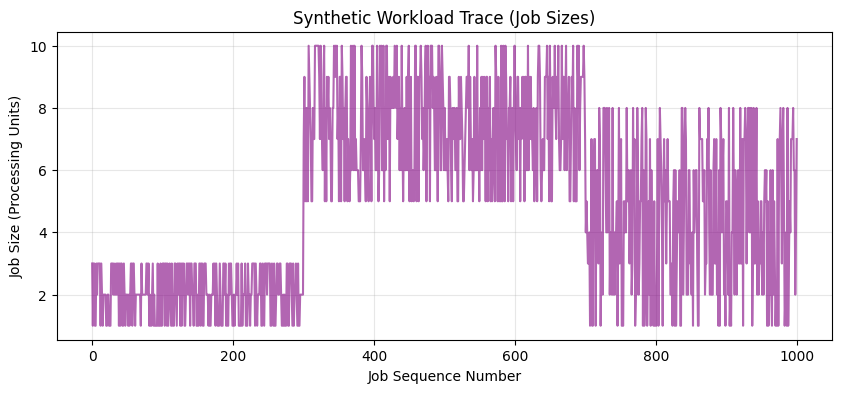

Generated 1000 jobs.
Sample jobs (first 10): [3 1 3 3 1 1 3 2 3 3]


In [ ]:
def generate_workload(n_jobs=1000):
    quiet_jobs = np.random.randint(1, 4, size=300)

    busy_jobs = np.random.randint(5, 11, size=400)

    mixed_jobs = np.random.randint(1, 9, size=300)

    workload = np.concatenate([quiet_jobs, busy_jobs, mixed_jobs])
    
    return workload

job_queue = generate_workload()

# Visualize the data to include in report (Data Analysis section)
plt.figure(figsize=(10, 4))
plt.plot(job_queue, color='purple', alpha=0.6)
plt.title("Synthetic Workload Trace (Job Sizes)")
plt.xlabel("Job Sequence Number")
plt.ylabel("Job Size (Processing Units)")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Generated {len(job_queue)} jobs.")
print(f"Sample jobs (first 10): {job_queue[:10]}")

In [ ]:
class CloudEnv:
    def __init__(self, workload):
        self.workload = workload
        self.n_servers = 3
        # Server Specs: [Processing Speed, Energy Cost per Job]
        self.server_specs = [
            {'speed': 3, 'energy': 2.0}, # Server 0 (Fast/Expensive)
            {'speed': 2, 'energy': 1.5}, # Server 1 (Medium)
            {'speed': 1, 'energy': 1.0}  # Server 2 (Slow/Green)
        ]
        self.reset()

    def reset(self):
        self.current_step = 0
        # Tracks how much work (units) is remaining on each server
        self.queues = [0.0, 0.0, 0.0] 
        return self._get_state()

    def _get_state(self):
        # State = [Queue_0, Queue_1, Queue_2, Incoming_Job_Size]
        if self.current_step < len(self.workload):
            job_size = self.workload[self.current_step]
        else:
            job_size = 0 # No job remaining
        return np.array(self.queues + [job_size])

    def step(self, action):
        job_size = self.workload[self.current_step]
        
        # Assign job to the selected server (action is 0, 1, or 2)
        # We add the job size to that server's existing queue
        self.queues[action] += job_size
        
        # Calculate Energy Cost (Immediate penalty for using this server)
        energy_penalty = self.server_specs[action]['energy']

        for i in range(self.n_servers):
            self.queues[i] = max(0, self.queues[i] - self.server_specs[i]['speed'])
            
        # Calculate Latency Cost (Penalty for keeping jobs waiting)
        # We use the sum of all queues as a proxy for system latency
        latency_penalty = sum(self.queues)
        
        # Total Reward
        # We weigh Latency higher than Energy to prioritize stability
        # Reward = -(Latency + lambda * Energy)
        reward = - (latency_penalty + 2.0 * energy_penalty)
        
        self.current_step += 1
        done = self.current_step >= len(self.workload)
        next_state = self._get_state()
        
        return next_state, reward, done
    
print("Environment Class defined.")

Environment Class defined.


In [ ]:
class QLearningAgent:
    def __init__(self, n_actions=3, alpha=0.1, gamma=0.99, epsilon=1.0):
        self.n_actions = n_actions
        self.alpha = alpha   # Learning Rate
        self.gamma = gamma   # Discount Factor (0.99 = cares much more about future)
        self.epsilon = epsilon  
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995 
        self.q_table = {}

    def _discretize_state(self, state):

        bins = [10, 20, 40]
        
        q0_bin = np.digitize(state[0], bins)
        q1_bin = np.digitize(state[1], bins)
        q2_bin = np.digitize(state[2], bins)
        job_size = int(state[3])
        
        return (q0_bin, q1_bin, q2_bin, job_size)

    def get_q_values(self, state_key):
        if state_key not in self.q_table:
            self.q_table[state_key] = np.zeros(self.n_actions)
        return self.q_table[state_key]

    def choose_action(self, state):
        state_key = self._discretize_state(state)
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)
        else:
            q_values = self.get_q_values(state_key)

            max_q = np.max(q_values)
            actions_with_max_q = [i for i in range(self.n_actions) if q_values[i] == max_q]
            return np.random.choice(actions_with_max_q)

    def update(self, state, action, reward, next_state):
        state_key = self._discretize_state(state)
        next_state_key = self._discretize_state(next_state)
        
        current_q = self.get_q_values(state_key)[action]
        max_future_q = np.max(self.get_q_values(next_state_key))
        
        new_q = current_q + self.alpha * (reward + self.gamma * max_future_q - current_q)
        self.q_table[state_key][action] = new_q

    def decay_exploration(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

In [ ]:

env = CloudEnv(job_queue)
agent = QLearningAgent()

n_episodes = 10000
history_rewards = []

print(f"Starting Training for {n_episodes} episodes...")

for episode in range(n_episodes):
    state = env.reset()
    total_reward = 0
    done = False
    
    while not done:
        # Choose Action
        action = agent.choose_action(state)
        
        # Take Action
        next_state, reward, done = env.step(action)
        
        # Learn (Update Q-Table)
        agent.update(state, action, reward, next_state)
        
        state = next_state
        total_reward += reward
        
    # Decay exploration rate after each episode
    agent.decay_exploration()
    history_rewards.append(total_reward)
    
    # Print progress every 50 episodes
    if (episode + 1) % 50 == 0:
        print(f"Episode {episode + 1}/{n_episodes} | Total Reward: {total_reward:.2f} | Epsilon: {agent.epsilon:.2f}")

print("Training Completed.")

Starting Training for 10000 episodes...
Episode 50/10000 | Total Reward: -325714.00 | Epsilon: 0.78
Episode 100/10000 | Total Reward: -281163.00 | Epsilon: 0.61
Episode 150/10000 | Total Reward: -328975.00 | Epsilon: 0.47
Episode 200/10000 | Total Reward: -274319.00 | Epsilon: 0.37
Episode 250/10000 | Total Reward: -271538.00 | Epsilon: 0.29
Episode 300/10000 | Total Reward: -317158.00 | Epsilon: 0.22
Episode 350/10000 | Total Reward: -290146.00 | Epsilon: 0.17
Episode 400/10000 | Total Reward: -279566.00 | Epsilon: 0.13
Episode 450/10000 | Total Reward: -298864.00 | Epsilon: 0.10
Episode 500/10000 | Total Reward: -275035.00 | Epsilon: 0.08
Episode 550/10000 | Total Reward: -272142.00 | Epsilon: 0.06
Episode 600/10000 | Total Reward: -284293.00 | Epsilon: 0.05
Episode 650/10000 | Total Reward: -297836.00 | Epsilon: 0.04
Episode 700/10000 | Total Reward: -303873.00 | Epsilon: 0.03
Episode 750/10000 | Total Reward: -338092.00 | Epsilon: 0.02
Episode 800/10000 | Total Reward: -305112.00 |

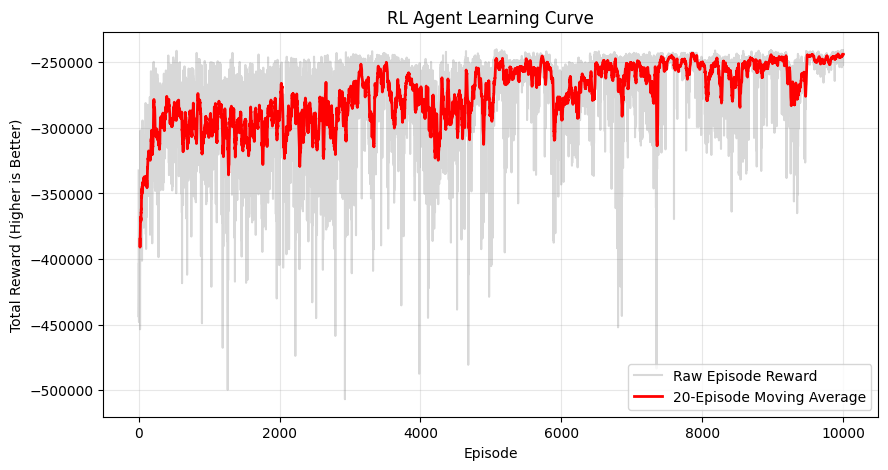

In [13]:
# Calculate a moving average to smooth out the noise and show the trend clearly
window = 20
smoothed_rewards = pd.Series(history_rewards).rolling(window=window).mean()

plt.figure(figsize=(10, 5))
# Plot the raw data in faint grey
plt.plot(history_rewards, color='gray', alpha=0.3, label='Raw Episode Reward')
# Plot the moving average in bold red
plt.plot(smoothed_rewards, color='red', linewidth=2, label=f'{window}-Episode Moving Average')

plt.title("RL Agent Learning Curve")
plt.xlabel("Episode")
plt.ylabel("Total Reward (Higher is Better)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Final Scores (Higher is Better, closer to 0):
RL Agent:    -243005.00
Round Robin: -410918.00
Random:      -437500.00


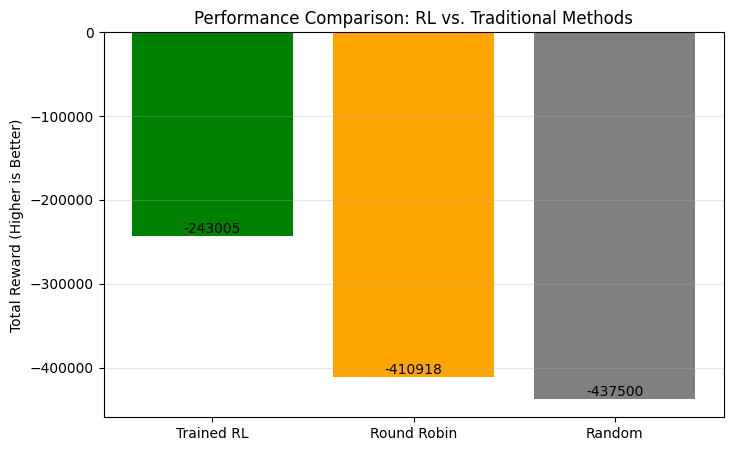

In [ ]:
def run_evaluation(agent=None, strategy='rl'):
    """
    Runs one episode with a specific strategy (no learning).
    Strategies: 'rl', 'random', 'round_robin'
    """
    state = env.reset()
    total_reward = 0
    total_energy = 0
    total_latency = 0
    done = False
    step_count = 0
    
    while not done:
        # Select Action based on strategy
        if strategy == 'rl':
            state_key = agent._discretize_state(state)
            action = np.argmax(agent.get_q_values(state_key))
            
        elif strategy == 'random':
            action = np.random.randint(3)
            
        elif strategy == 'round_robin':
            action = step_count % 3
            
        # Execute
        next_state, reward, done = env.step(action)
        
        # Track metrics
        total_reward += reward
        # We assume the reward formula was R = -(Latency + 2*Energy).
        # We can loosely decouple them for analysis if we tracked them separately in env,
        # but here we will just use the Total Reward as the main metric.
        
        state = next_state
        step_count += 1
        
    return total_reward

rl_score = run_evaluation(agent, strategy='rl')

random_score = run_evaluation(strategy='random')

rr_score = run_evaluation(strategy='round_robin')

print(f"Final Scores (Higher is Better, closer to 0):")
print(f"RL Agent:    {rl_score:.2f}")
print(f"Round Robin: {rr_score:.2f}")
print(f"Random:      {random_score:.2f}")

# Visualization
strategies = ['Trained RL', 'Round Robin', 'Random']
scores = [rl_score, rr_score, random_score]

plt.figure(figsize=(8, 5))
# Note: Scores are negative, so we look for the tallest bar (least negative)
bars = plt.bar(strategies, scores, color=['green', 'orange', 'gray'])
plt.title("Performance Comparison: RL vs. Traditional Methods")
plt.ylabel("Total Reward (Higher is Better)")
plt.grid(axis='y', alpha=0.3)

# Add text labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.0f}',
             ha='center', va='bottom')

plt.show()